In [11]:
%pip install datasets pandas pillow

Note: you may need to restart the kernel to use updated packages.


In [12]:
from datasets import load_dataset

dataset = load_dataset("BoKelvin/SLAKE")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 9835
    })
    validation: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2099
    })
    test: Dataset({
        features: ['img_name', 'location', 'answer', 'modality', 'base_type', 'answer_type', 'question', 'qid', 'content_type', 'triple', 'img_id', 'q_lang'],
        num_rows: 2094
    })
})


In [13]:
print(dataset["train"][0])

{'img_name': 'xmlab1/source.jpg', 'location': 'Abdomen', 'answer': 'MRI', 'modality': 'MRI', 'base_type': 'vqa', 'answer_type': 'OPEN', 'question': 'What modality is used to take this image?', 'qid': 0, 'content_type': 'Modality', 'triple': ['vhead', '_', '_'], 'img_id': 1, 'q_lang': 'en'}


In [14]:
import os
import shutil

# Create folder for images
image_folder = "slake_images"
os.makedirs(image_folder, exist_ok=True)

# Save images from all splits
for split in ["train", "validation", "test"]:
    for i, row in enumerate(dataset[split]):
        image_path = row["img_name"]   # image path string
        
        # check if file exists
        if os.path.exists(image_path):
            new_name = f"{split}_{i}.jpg"
            destination = os.path.join(image_folder, new_name)
            shutil.copy(image_path, destination)

print("All images saved successfully!")

All images saved successfully!


In [15]:
import pandas as pd

rows = []

for split in ["train", "validation", "test"]:
    for i, row in enumerate(dataset[split]):
        rows.append({
            "split": split,
            "image_name": f"{split}_{i}.jpg",
            "question": row["question"],
            "answer": row["answer"]
        })

df = pd.DataFrame(rows)

df.to_csv("slake_dataset.csv", index=False)

print("CSV saved successfully!")
print(df.head())

CSV saved successfully!
   split   image_name                                           question  \
0  train  train_0.jpg          What modality is used to take this image?   
1  train  train_1.jpg  Which part of the body does this image belong to?   
2  train  train_2.jpg            What is the mr weighting in this image?   
3  train  train_3.jpg                    Does the picture contain liver?   
4  train  train_4.jpg                   Does the picture contain kidney?   

    answer  
0      MRI  
1  Abdomen  
2       T2  
3      Yes  
4       No  


In [16]:
import os
print(os.getcwd())

C:\Users\HP


In [18]:
import os
print("Current notebook path:")
print(os.getcwd())

Current notebook path:
C:\Users\HP


In [19]:
import os
print(os.path.exists("slake_images"))

True


In [20]:
import os
print(os.path.abspath("slake_images"))

C:\Users\HP\slake_images


In [21]:
import os

files = os.listdir("slake_images")
print("Total images:", len(files))
print(files[:10])

Total images: 2
['imgs', '__MACOSX']


In [22]:
import os

print(os.listdir("slake_images/imgs")[:20])

['.DS_Store', 'xmlab0', 'xmlab1', 'xmlab10', 'xmlab100', 'xmlab101', 'xmlab102', 'xmlab103', 'xmlab104', 'xmlab105', 'xmlab106', 'xmlab107', 'xmlab108', 'xmlab109', 'xmlab11', 'xmlab110', 'xmlab111', 'xmlab112', 'xmlab113', 'xmlab114']


In [23]:
import os
import shutil

source_folder = "slake_images/imgs"
destination_folder = "all_slake_images"

os.makedirs(destination_folder, exist_ok=True)

count = 0

for root, dirs, files in os.walk(source_folder):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            source_path = os.path.join(root, file)
            dest_path = os.path.join(destination_folder, file)

            shutil.copy(source_path, dest_path)
            count += 1

print("Total images copied:", count)
print("Saved in folder:", destination_folder)

Total images copied: 1284
Saved in folder: all_slake_images


In [24]:
print(len(os.listdir("all_slake_images")))

2


In [25]:
import shutil

source_root = "slake_images/imgs"   # folder that contains xmlab folders
destination = "final_slake_images"

os.makedirs(destination, exist_ok=True)

count = 0

for folder in os.listdir(source_root):
    folder_path = os.path.join(source_root, folder)

    if os.path.isdir(folder_path):
        image_path = os.path.join(folder_path, "source.jpg")

        if os.path.exists(image_path):
            new_name = f"{folder}.jpg"
            shutil.copy(image_path, os.path.join(destination, new_name))
            count += 1

print("Total extracted images:", count)

Total extracted images: 642


In [26]:
print(len(os.listdir("final_slake_images")))

642


In [27]:
print(os.listdir("final_slake_images")[:10])

['xmlab0.jpg', 'xmlab1.jpg', 'xmlab10.jpg', 'xmlab100.jpg', 'xmlab101.jpg', 'xmlab102.jpg', 'xmlab103.jpg', 'xmlab104.jpg', 'xmlab105.jpg', 'xmlab106.jpg']


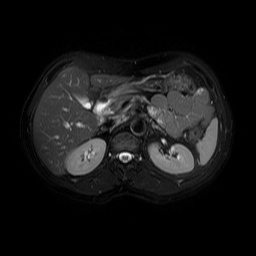

In [28]:
from PIL import Image
from IPython.display import display
import os

files = os.listdir("final_slake_images")

img = Image.open(os.path.join("final_slake_images", files[0]))
display(img)

In [29]:
print(len(os.listdir("all_slake_images")))

2


In [30]:
import os

folder_path = "final_slake_images"

# count only image files
image_files = [
    file for file in os.listdir(folder_path)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images saved:", len(image_files))

Total images saved: 642


In [31]:
import os

folder_name = "final_slake_images"   # change if you used another name
print("Folder exists:", os.path.exists(folder_name))
print("Full path:", os.path.abspath(folder_name))

Folder exists: True
Full path: C:\Users\HP\final_slake_images
